In [1]:
!pip install openpyxl

# **Introduction**

Customer churn refers to the situation where customers stop using a company's service. In competitive industries, retaining customers is as important as acquiring new ones. Therefore, being able to predict whether a customer is likely to churn can help businesses take proactive actions to improve retention. In this project, the main goal is to identify the most effective model for predicting customer churn and to understand how different models perform on the same dataset.


# **List of Main Steps**

Here are the main steps that we will go through:

(1) Get the Data

(2) Data Exploration(EDA)

(3) Prepare the Data for Machine Learning Algorithms

(4) Model Training

(5) Evaluate the model outcomes

(6) Conculsion

# **Importing Related Libararies**

The following are the libraries that will be used throughout the challenge.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc

#**Get the Dataset**

In [3]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [4]:
path = "/content/drive/My Drive/GlobalNet 2nd Interview Assessment/CPSD.xlsx"
cusdf = pd.read_excel(path)

## **Take a Quick Look at the Data Structure**

In [5]:
cusdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Customer ID                150 non-null    object        
 1   Customer Name              150 non-null    object        
 2   Creation Date              150 non-null    datetime64[ns]
 3   Activation Date            150 non-null    datetime64[ns]
 4   Service Type               150 non-null    object        
 5   Customer Category          150 non-null    object        
 6   Township                   150 non-null    object        
 7   Plan Name                  150 non-null    object        
 8   Status                     150 non-null    object        
 9   Last Active Date           149 non-null    datetime64[ns]
 10  Active Month               149 non-null    float64       
 11  Active Days                149 non-null    float64       
 12  Suspend 

In [6]:
cusdf.head()

,Customer ID,Customer Name,Creation Date,Activation Date,Service Type,Customer Category,Township,Plan Name,Status,Last Active Date,...,Suspend Duration in Days,No Of MRC Invoice,No Of OTI Invoice,Total MRC Invoice Amount,Total OTI Invoice Amount,Total Payment,Balance,Advance Benefit Offered,Advance Benefit Consumed,Advance Benefit Balance
0,YGN00000001,ZIN M NYI,2021-04-20 13:36:34,2021-05-29 17:55:33,Postpaid,"Family,Condo",North Dagon,Eco,Subscriber Debt,2024-01-16 10:34:07,...,805.6229,31.0,NaN,834966,0,0,0,0,0,0
1,YGN00000002,MON MON THEINT,2022-05-19 15:02:34,2022-05-21 15:19:22,Postpaid,"Family,Condo",Sanchaung,ATS,Subscriber Debt,2023-10-12 11:15:50,...,889.6640,17.0,NaN,543418,0,0,0,0,0,0
2,YGN00000003,DAW WIN MAR,2023-02-15 16:53:53,2023-02-17 15:50:40,Postpaid,"Family,Condo",Thaketa,XXSPlus_Special,Suspension Under Request,2023-12-12 15:26:39,...,898.8908,9.0,NaN,288885,0,0,0,0,0,0
3,YGN00000004,MA HLA HLA WIN,2026-01-19 13:12:11,2026-01-22 14:44:36,prepaid,Family,Yankin,Prepaid_34_YGN,Active,2026-03-18 23:59:59,...,0.0000,NaN,1.0,0,85900,0,0,0,0,0
4,YGN00000005,Maung MYO Neint,2021-04-28 11:02:23,2021-05-06 20:07:39,Postpaid,"Family,Condo",Hlaingthaya,XXSPlus_Special,Termination,2025-09-28 20:52:08,...,4.0816,53.0,NaN,1211261,0,-278300,-1687,0,0,0


In [7]:
cusdf.describe()

,Creation Date,Activation Date,Last Active Date,Active Month,Active Days,Suspend Duration in Month,Suspend Duration in Days,No Of MRC Invoice,No Of OTI Invoice,Total MRC Invoice Amount,Total OTI Invoice Amount,Total Payment,Balance,Advance Benefit Offered,Advance Benefit Consumed,Advance Benefit Balance
count,150,150,149,149.000000,149.000000,149.000000,149.000000,125.000000,35.000000,1.500000e+02,150.000000,1.500000e+02,150.000000,150.000000,150.000000,150.000000
mean,2021-09-14 12:12:52.926666496,2021-10-18 04:36:33.753333248,2024-07-12 12:42:54.516778752,29.583893,870.663538,13.422819,386.705613,36.592000,3.200000,1.077273e+06,85981.166667,-1.352810e+05,-15136.886667,-18883.000000,12912.646667,-5970.353333
min,2017-05-04 00:00:00,2017-05-24 00:00:00,2019-01-31 09:19:21,1.000000,0.003100,0.000000,0.000000,3.000000,1.000000,0.000000e+00,0.000000,-1.328881e+06,-607200.000000,-355350.000000,0.000000,-246100.000000
25%,2020-04-22 18:53:34,2020-04-30 04:20:28.500000,2023-07-12 11:52:30,8.000000,233.243500,1.000000,1.998900,14.000000,1.000000,2.437112e+05,0.000000,-1.577688e+05,0.000000,0.000000,0.000000,0.000000
50%,2021-10-05 00:07:56.500000,2021-10-28 15:01:33.500000,2024-12-12 11:07:49,25.000000,726.694100,3.000000,84.984800,34.000000,2.000000,8.404600e+05,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000
75%,2022-12-28 20:52:51.249999872,2023-02-08 14:14:29,2026-03-18 23:59:59,47.000000,1406.810400,25.000000,739.383000,52.000000,3.000000,1.614735e+06,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000
max,2026-02-14 12:44:18,2026-02-16 12:03:31,2026-03-18 23:59:59,95.000000,2823.278600,67.000000,1985.488600,95.000000,16.000000,7.200822e+06,738300.000000,0.000000e+00,0.000000,0.000000,232300.000000,0.000000
std,NaN,NaN,NaN,23.925871,717.769393,15.836658,475.930497,23.903062,3.197425,1.150662e+06,184972.352844,2.539166e+05,71101.761669,54549.781027,37932.842615,25956.098025


In [8]:
cusdf["Status"].value_counts()

,count
Status,
Active,55
Termination,49
Subscriber Debt,35
Suspension Under Request,8
Validity Expire,2
Suspension Permanent,1


/tmp/ipykernel_33582/428420556.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Status', data=cusdf, palette='pastel')


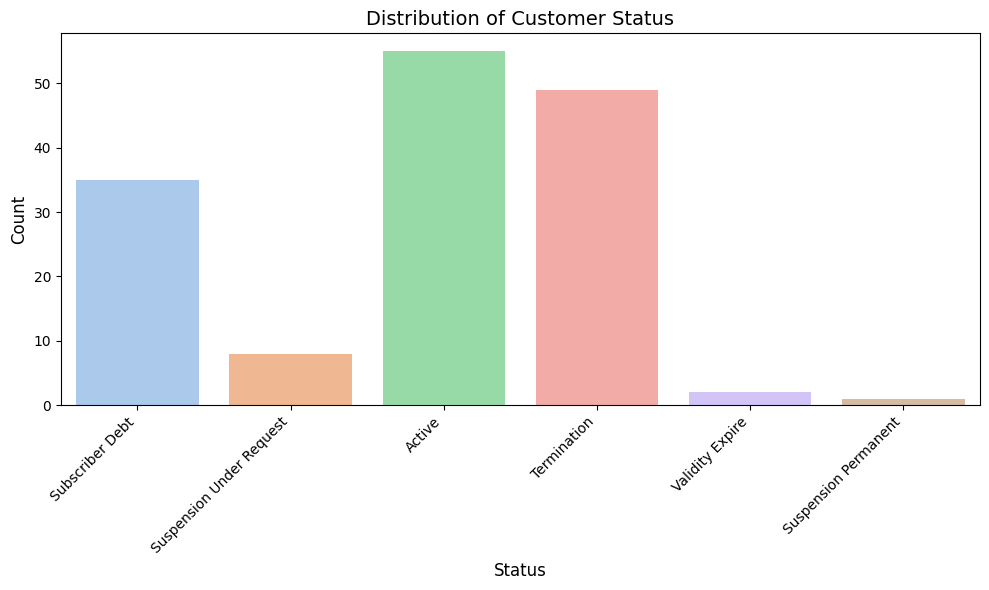

In [9]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Status', data=cusdf, palette='pastel')
plt.title('Distribution of Customer Status', fontsize=14)
plt.xlabel('Status', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

For the target class, The dataset contains multiple customer status categories rather than a direct binary churn label. To align with the churn prediction objective, the "Status" column was transformed into a binary target variable, where "Active" customers were labeled as non-churn (0), and all other statuses indicating inactivity or service disruption were labeled as churn (1).

let's see which other features has strongly related with the target variable "Status". To prevent the data leakage, a new feature column "churn_label" will be created.

In [10]:
cusdf["churn_label"] = cusdf["Status"].apply(
    lambda x: 0 if x == "Active" else 1)

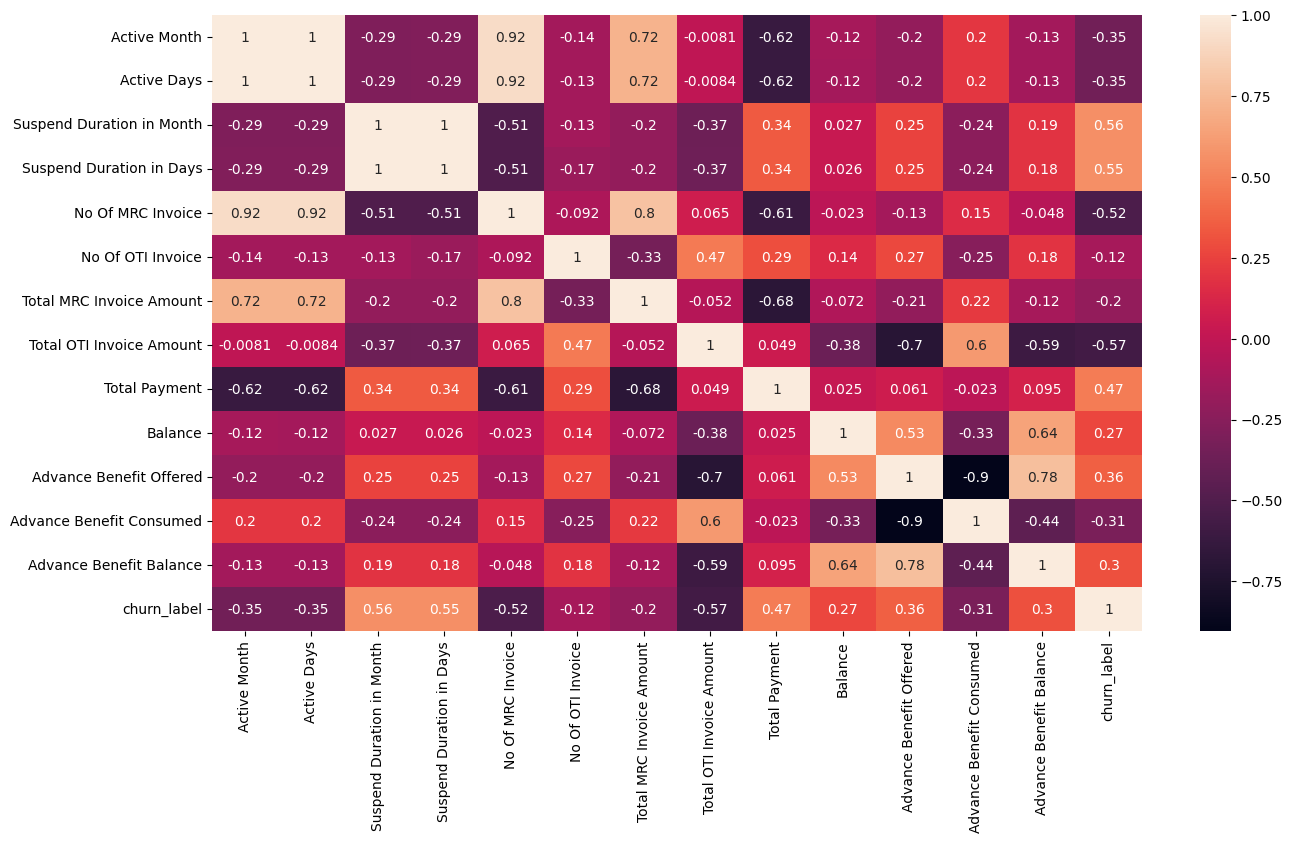

In [11]:
numeric_data = cusdf.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(15, 8))
sns.heatmap(numeric_data.corr(), annot=True)
plt.show()

The analysis shows that suspension duration has a moderately strong positive correlation with churn, suggesting that customers who experience longer suspension periods are more likely to leave the service. This aligns with business intuition, as service disruptions can negatively impact customer satisfaction. Additionally, features like active days show negative correlation, indicating that more engaged users are less likely to churn.

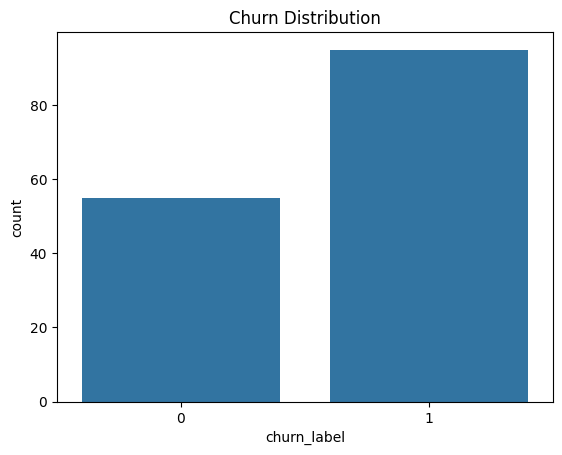

In [12]:
sns.countplot(x='churn_label', data=cusdf)
plt.title("Churn Distribution")
plt.show()

From the chart, we can observe that there are more customers in the churned group (churn_label = 1) compared to the non-churned group (churn_label = 0). This indicates a slight class imbalance in the dataset, with churned customers forming the majority.


Although the imbalance is not extremely severe, it is important to consider during model training to avoid bias toward the majority class. Stratified sampling will later be used to preserve this distribution in both training and testing sets.

# **Exploratory Data Analysis**

We wil now explore and visulaize the data to gain insights.

## **Looking for missing values**

In [13]:
cusdf.isnull().sum()

,0
Customer ID,0
Customer Name,0
Creation Date,0
Activation Date,0
Service Type,0
Customer Category,0
Township,0
Plan Name,0
Status,0
Last Active Date,1


In [14]:
missing_percentage = cusdf.isnull().mean() * 100
missing_percentage.sort_values(ascending=False)

,0
No Of OTI Invoice,76.666667
No Of MRC Invoice,16.666667
Active Month,0.666667
Suspend Duration in Month,0.666667
Active Days,0.666667
Last Active Date,0.666667
Suspend Duration in Days,0.666667
Customer ID,0.000000
Plan Name,0.000000
Township,0.000000


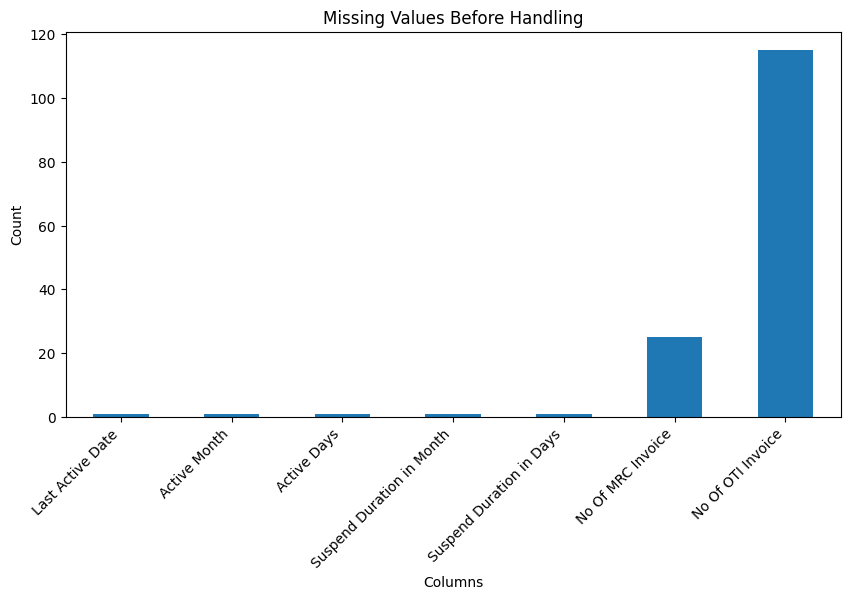

In [15]:
missing_before = cusdf.isnull().sum()

missing_before = missing_before[missing_before > 0]

missing_before.plot(kind='bar', figsize=(10,5))
plt.title("Missing Values Before Handling")
plt.xlabel("Columns")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.show()

From the initial data exploration, several columns contain missing values. The most significant ones are:

- **No Of OTI Invoice** (115 missing values)
- **No Of MRC Invoice** (25 missing values)
- A few columns with minor missing values (Last Active Date, Active Month, Active Days, Suspend Duration in Month, Suspend Duration in Days)

Instead of treating all missing values the same way, we consider the business meaning behind each feature. As for **No Of OTI Invoice** column, a large number of missing values suggests that these customers may not have any OTI invoices. Therefore, missing values are assumed to represent **0 (no invoice)**.
Next, In **No Of MRC Invoice**, Missing values may indicate that no monthly recurring charge invoices were generated. Thus, missing values are also treated as **0**. Last but not least, for **Time-related features** columns, since the number of missing values is very small (only 1 row), these can be safely filled using **median values** to avoid distortion.



## **Looking for outliers**

In [16]:
numeric_cols = cusdf.select_dtypes(include=['int64','float64']).columns

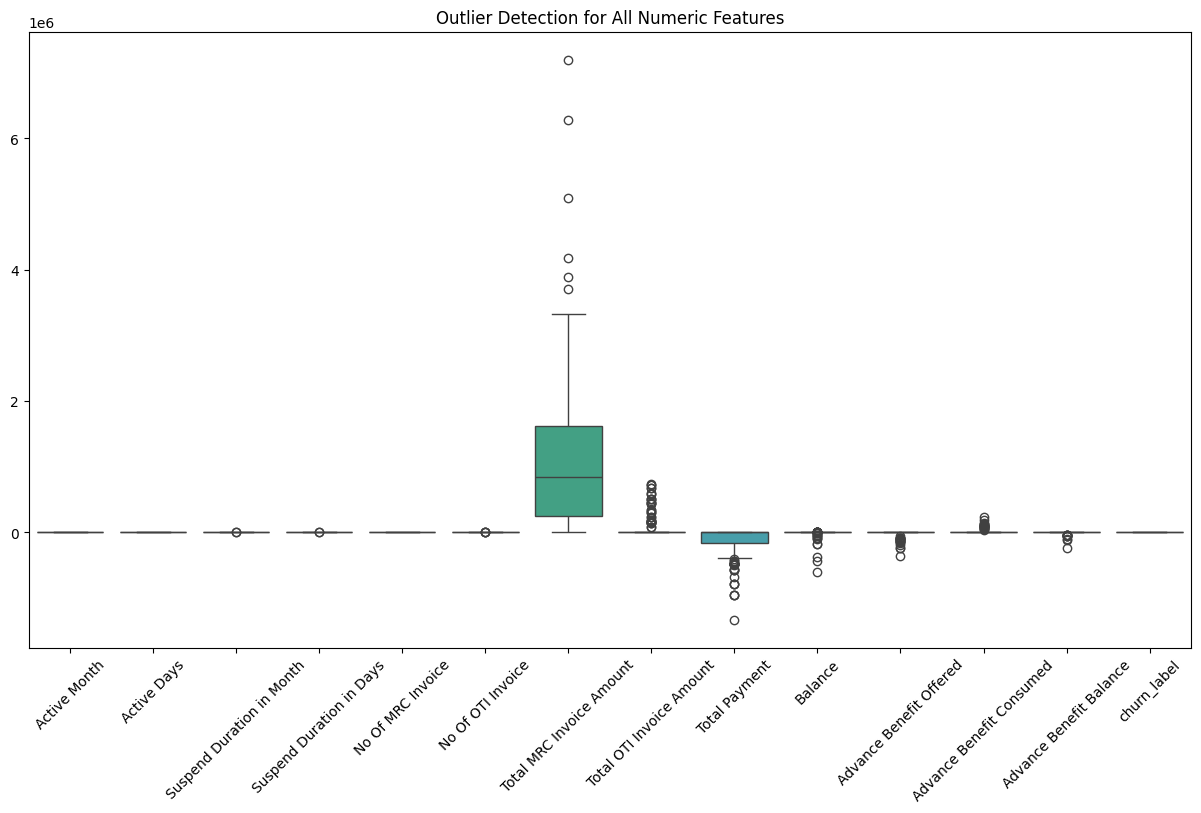

In [17]:
plt.figure(figsize=(15,8))
sns.boxplot(data=cusdf[numeric_cols])
plt.xticks(rotation=45)
plt.title("Outlier Detection for All Numeric Features")
plt.show()

Let's take a closer look again for three behaviorally meaningful columns : Total Payment, Active Days and Balance.

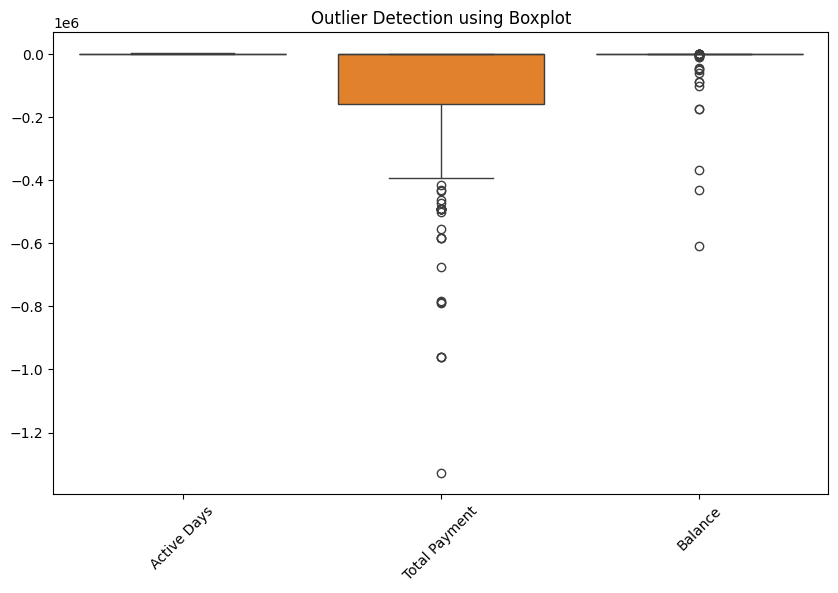

In [18]:
plt.figure(figsize=(10,6))
sns.boxplot(data=cusdf[['Active Days', 'Total Payment', 'Balance']])
plt.xticks(rotation=45)
plt.title("Outlier Detection using Boxplot")
plt.show()

Some financial-related features such as Total Payment, Balance, and Advance Benefit columns contain negative values. These are assumed to represent financial liabilities, refunds, or accounting adjustments rather than data errors. Therefore, these values were preserved as they may provide meaningful insights into customer behavior and churn risk.

<Axes: xlabel='churn_label', ylabel='Total Payment'>

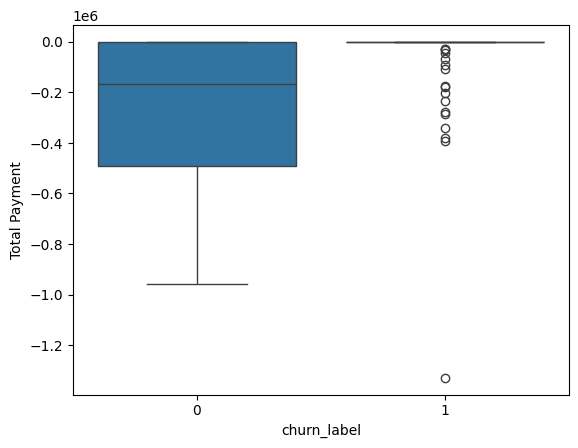

In [19]:
sns.boxplot(x='churn_label', y='Total Payment', data=cusdf)

When I analyze the relationship between **Total Payment** and the target variable **churn_label**,I made several key observations.

1. Customers who did not churn (churn_label = 0) show a wider distribution of Total Payment values, indicating more variability in their payment behavior.
2.  Customers who churned (churn_label = 1) appear to have a more concentrated distribution, but with several noticeable outliers.
3. A number of negative values are present in both groups, which are assumed to represent financial adjustments, debts, or refunds rather than errors.

Thus, The differences in distribution suggest that **Total Payment may be an important feature for predicting churn**. In particular, Customers with irregular or extreme payment values including large negative values may have a higher likelihood of churning. The presence of multiple outliers in the churned group indicates that unusual financial behavior could be associated with customer dissatisfaction or service discontinuation.

Overall, Total Payment provides meaningful insight into customer financial activity and its relationship with churn. However, further modeling is required to confirm its predictive power.

## **Categorical Features vs Churn**

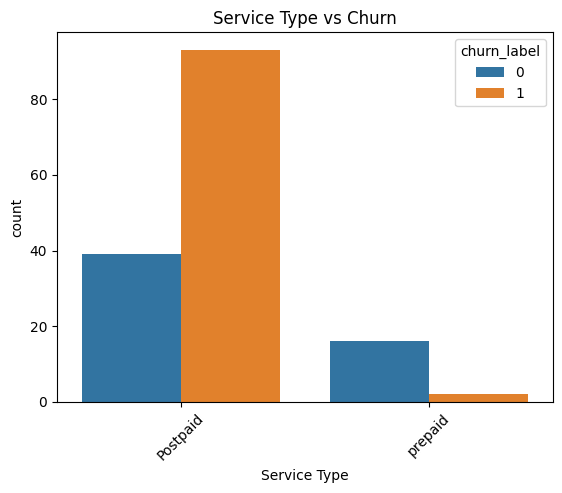

In [20]:
sns.countplot(x='Service Type', hue='churn_label', data=cusdf)
plt.xticks(rotation=45)
plt.title("Service Type vs Churn")
plt.show()

From the visualization, we can see that the majority of customers belong to the **Postpaid** service type. Among Postpaid users, a significantly higher number of customers have churned (churn_label = 1) compared to those who did not churn. In contrast, **Prepaid** customers show a much lower churn count, with most customers remaining active.

This suggests that **Service Type may have a strong relationship with churn behavior**:

- Postpaid customers appear to have a higher tendency to churn.
- Prepaid customers seem more stable with lower churn rates.

This difference may be due to factors such as billing structure, contract commitments, or usage patterns.Therefore, `Service Type` is likely to be an important feature for predicting customer churn and should be included in the model.

# **Data Preprocessing**

## **Handling categorical and numerical columns**

We shall exclude the status, Customer ID, Customer Name, and target variable "churn_label" because they need special handling.

The dataset contains several date-related columns such as Creation Date, Activation Date, and Last Active Date. While these features may contain useful temporal information, raw date values are not directly suitable for machine learning models.

Since extracting meaningful features requires additional preprocessing, these columns were removed at this stage to maintain a clean and simple modeling pipeline.

Future improvements may include deriving time-based features from these columns to enhance model performance.

In [21]:
features = cusdf.drop(columns=[
    "Status",
    "churn_label",
    "Customer ID",
    "Customer Name",
    "Creation Date",
    "Activation Date",
    "Last Active Date"
])

target = cusdf["churn_label"]

We shall now split the test set and training set.

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42,
    stratify=target
)

In [23]:
categorical_columns = X_train.select_dtypes(include=["object"]).columns.tolist()
numerical_columns = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical columns:", categorical_columns)
print("Numerical columns:", numerical_columns)

Categorical columns: ['Service Type', 'Customer Category', 'Township', 'Plan Name']
Numerical columns: ['Active Month', 'Active Days', 'Suspend Duration in Month', 'Suspend Duration in Days', 'No Of MRC Invoice', 'No Of OTI Invoice', 'Total MRC Invoice Amount', 'Total OTI Invoice Amount', 'Total Payment', 'Balance', 'Advance Benefit Offered', 'Advance Benefit Consumed', 'Advance Benefit Balance']


## **Feature Scaling**

In [24]:
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numerical", numerical_pipeline, numerical_columns),
    ("categorical", categorical_pipeline, categorical_columns)
])

Numerical features in the dataset have very different ranges, especially financial variables such as invoice amounts, payments, and balances, which are much larger in scale than features like active days or suspension duration.

To ensure that numerical features contribute more fairly to the model, **StandardScaler** was applied as part of the preprocessing pipeline.

At the same time, missing values were handled within the same pipeline:

- numerical columns were imputed using the **median**
- categorical columns were imputed using the **most frequent value**
- categorical features were transformed using **One-Hot Encoding**

This preprocessing pipeline was fitted on the training set only and then applied to the test set, preventing data leakage and improving scalability.

# **Model Developement**


In model development, A machine learning pipeline will be applied to combine preprocessing and classification into a single workflow. This ensures that the same preprocessing steps are consistently applied during both training and prediction.

## **Model Training**

To identify the most suitable model for churn prediction, I will use three different classification algorithms to evaluate:

- Logistic Regression
- Decision Tree
- Random Forest

Each model was integrated into a pipeline that includes preprocessing steps such as imputation, encoding, and scaling. This ensures consistent data transformation across all models.

The models were evaluated using accuracy on the test set, and their performance was compared to determine the most effective approach.

In [25]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

In [26]:
results = {}

for model_name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test) #predict on the X_test

    accuracy = accuracy_score(y_test, y_pred)

    results[model_name] = accuracy

    print(f"{model_name} Accuracy: {accuracy:.4f}")

Logistic Regression Accuracy: 0.9333
Decision Tree Accuracy: 0.8667
Random Forest Accuracy: 0.9000


The results indicate that Logistic Regression provides the best performance among the evaluated models, and will be used as the final model for further evaluation.

In [27]:
results_df = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"])
results_df = results_df.sort_values(by="Accuracy", ascending=False)

results_df

,Model,Accuracy
0,Logistic Regression,0.933333
2,Random Forest,0.900000
1,Decision Tree,0.866667


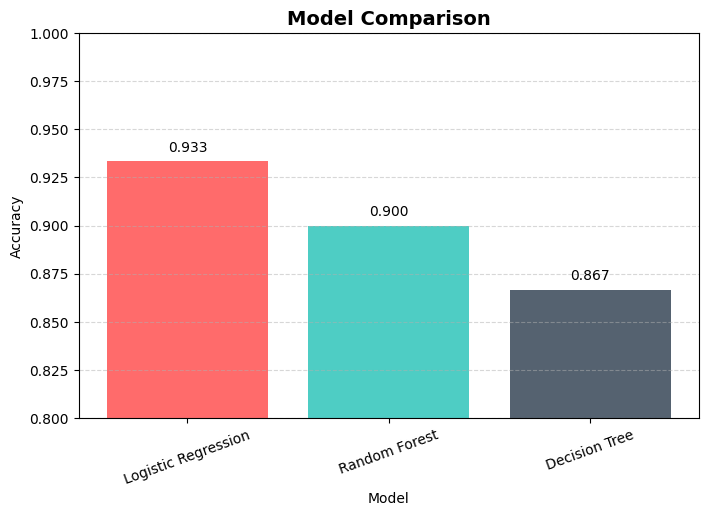

In [28]:
colors = ["#FF6B6B", "#4ECDC4", "#556270"]

plt.figure(figsize=(8,5))
plt.bar(results_df["Model"], results_df["Accuracy"], color=colors)
plt.title("Model Comparison", fontsize=14, fontweight="bold")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0.8, 1.0)

for i, v in enumerate(results_df["Accuracy"]):
    plt.text(i, v + 0.005, f"{v:.3f}", ha='center', fontsize=10)

plt.xticks(rotation=20)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# **Evaluation**

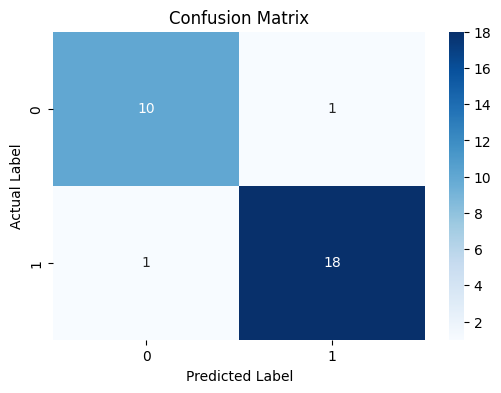

In [29]:
lr_model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", models['Logistic Regression'])
    ])

lr_model_pipeline.fit(X_train, y_train)
y_pred = lr_model_pipeline.predict(X_test)
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

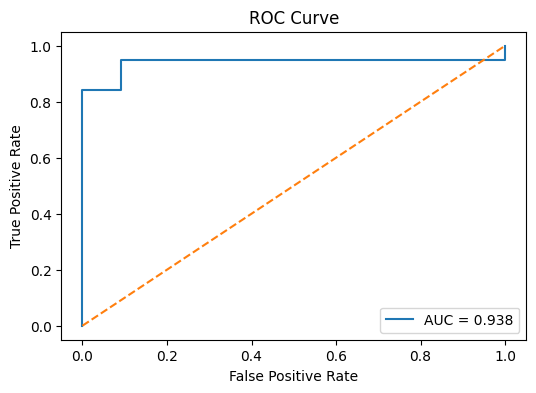

In [30]:
y_prob = lr_model_pipeline.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

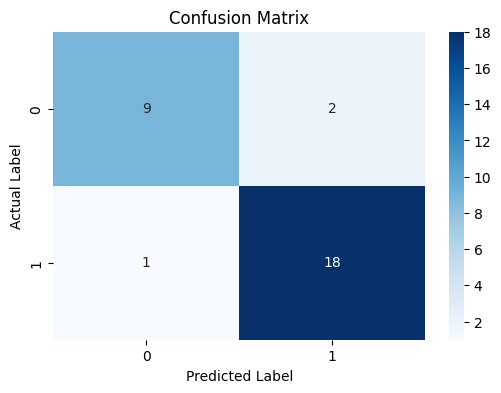

In [31]:
rf_model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", models['Random Forest'])
    ])

rf_model_pipeline.fit(X_train, y_train)
y_pred = rf_model_pipeline.predict(X_test)
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

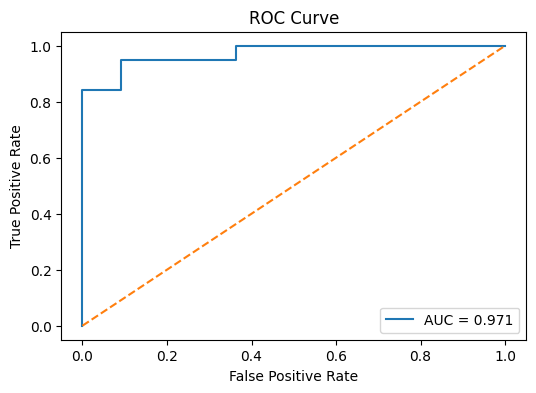

In [32]:
y_prob = rf_model_pipeline.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

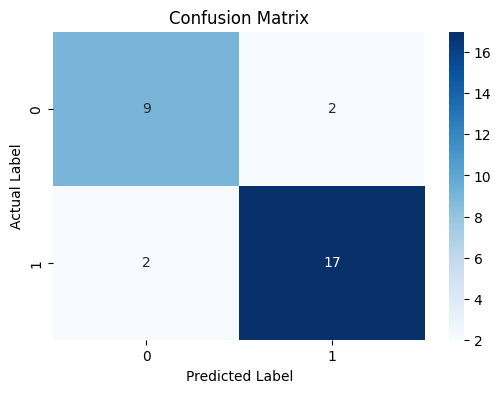

In [33]:
dt_model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", models['Decision Tree'])
    ])

dt_model_pipeline.fit(X_train, y_train)
y_pred = dt_model_pipeline.predict(X_test)
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

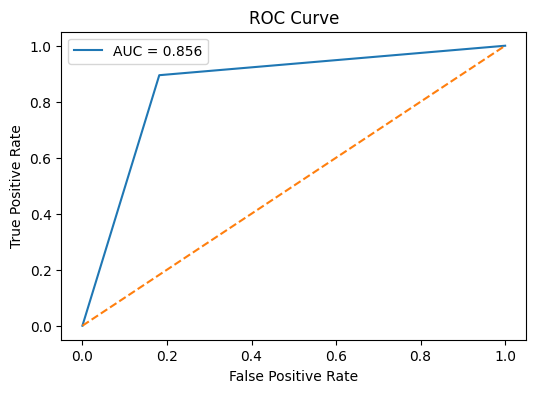

In [34]:
y_prob = dt_model_pipeline.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

Although Logistic Regression achieved the highest accuracy, Random Forest produced a higher AUC score.

This indicates that while Logistic Regression performs better at making final classification decisions, Random Forest has a stronger ability to distinguish between classes across different probability thresholds.

This difference highlights the importance of evaluating models using multiple metrics rather than relying solely on accuracy.

# **Final Model Selection and Conclusion**



In [40]:
#LR TRAIN performance
y_train_pred = lr_model_pipeline.predict(X_train)
train_acc = accuracy_score(y_train, y_train_pred)

#LR TEST performance
y_test_pred = lr_model_pipeline.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 0.9833333333333333
Test Accuracy: 0.9333333333333333


In [39]:
from sklearn.metrics import roc_auc_score

train_auc = roc_auc_score(y_train, lr_model_pipeline.predict_proba(X_train)[:,1])
test_auc = roc_auc_score(y_test, lr_model_pipeline.predict_proba(X_test)[:,1])

print("Train AUC:", train_auc)
print("Test AUC:", test_auc)

Train AUC: 0.9994019138755981
Test AUC: 0.9377990430622009


Among these models, **Logistic Regression achieved the highest accuracy of 93.33%**, outperforming the other models. This indicates that the relationship between the features and the target variable can be effectively captured using a linear decision boundary.

The strong performance of Logistic Regression suggests that the dataset is relatively well-structured, with meaningful patterns that do not require highly complex models to be captured.

In addition to accuracy, further evaluation using the confusion matrix and ROC curve demonstrated that the model is capable of distinguishing between churn and non-churn customers effectively.

Given its high performance, simplicity, and interpretability, Logistic Regression was selected as the final model for this task.

Although there is a slight difference between training and testing performance, the gap is relatively small (approximately 5%), indicating only mild overfitting. Given the small dataset size, this behavior is expected.

Overall, this model can serve as a reliable baseline for predicting customer churn and can be further improved in future work through feature engineering or hyperparameter tuning if needed.

# Export the final model

In [35]:
import joblib

joblib.dump(lr_model_pipeline, "/content/drive/My Drive/GlobalNet 2nd Interview Assessment/churn_model.pkl")

['/content/drive/My Drive/GlobalNet 2nd Interview Assessment/churn_model.pkl']